## Loading Libraries

In [30]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile
import geopandas as gpd
from urllib.parse import urlencode

In [31]:
citibike_df = pd.read_csv("../Data/citibike/JC/JC2025_Enriched.csv")

### Downloading Data

In [32]:
from posixpath import join

In [33]:
url='https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/citibike/JC/jersey-city-neighborhoods.geojson'

In [34]:
def geojson_downloader(url:str, name:str, path:str)->gpd.GeoDataFrame:
    df = gpd.read_file(url)
    df.to_file(f'{path}/{name}.geojson'),
    driver='GeoJSON'
    print(f'The {name}.geojson was successfully stored in {path}')
    return df


In [35]:
jersey_city=geojson_downloader(
    url=url,name='jercey-city-neighborhoods',path='../Data/citibike/JC'
)

The jercey-city-neighborhoods.geojson was successfully stored in ../Data/citibike/JC


In [40]:
OUTPUT_DIR = "../Data/citibike/"

In [41]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 3.6 KB


In [42]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
jersey_city = jersey_city.to_crs("EPSG:4326")

In [44]:
citibike_df.shape

(998281, 22)

Matplotlib is building the font cache; this may take a moment.


<Axes: >

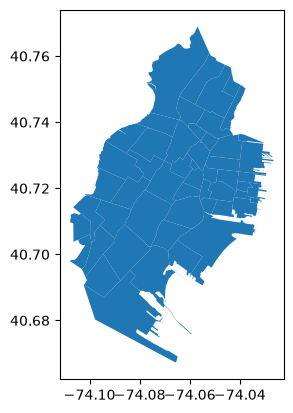

In [45]:
jersey_city.plot()

### Station Level Analysis